# Profiling in PyTorch

This notebook follows the [Profiling in PyTorch](https://huggingface.co/blog/torch-profiler) Hugging Face tutorial. 
All results were obtained on a laptopn with the following configuration:
* CPU: 13th Gen Intel(R) Core(TM) i7-13700HX
* GPU: NVIDIA GeForce RTX 4060 Max-Q / Mobile
* RAM: 32GiB SODIMM Synchronous 4800 MHz

In [1]:
import matplotlib.pyplot as plt
import os
import torch
from math import sqrt

## Part 1: A Beginner's Guide to `torch.profiler`

### Generating profiling tables and traces

The following code runs and profiles a function `fn` consisting of matrix multiplication and addition.

In [2]:
# Parameters
size = 4096
dtype = torch.bfloat16
compile_mode = None
warmup_steps = 10240 // size
profile_steps = 409600 // size
device = "cuda"
trace_dir = "./temp/01_matmul_add"
schedule_wait_steps = 1
schedule_warmup_steps = 1
schedule_active_steps = 3

# Function to be profiled (matrix multiplication and addition)
def fn(x, w, b):
    return torch.add(torch.matmul(x, w), b)

# Optionally compile it
fn = torch.compile(fn, mode=compile_mode) if compile_mode is not None else fn

# Annotate the function
def step():
    with torch.profiler.record_function("matmul_add"):
        return fn(x, w, b)

# Generate random inputs, weights, and biases
x = torch.randn(size, size, device=device, dtype=dtype)
w = torch.randn(size, size, device=device, dtype=dtype)
b = torch.randn(size, size, device=device, dtype=dtype)

# Optional warmup
if warmup_steps > 0:
    for _ in range(warmup_steps):
        step()
    torch.cuda.synchronize()

# Create the directory to store the trace
os.makedirs(trace_dir, exist_ok=True)

# Names for the trace files
tag = f"{size}_{dtype}_{warmup_steps}_{profile_steps}_{compile_mode}"
table_path = os.path.join(trace_dir, f"{tag}.txt")
trace_path = os.path.join(trace_dir, f"{tag}.json")

# Run profiling
schedule = torch.profiler.schedule(
    wait=schedule_wait_steps, 
    warmup=schedule_warmup_steps, 
    active=schedule_active_steps, 
    repeat=1)
with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CPU,
        torch.profiler.ProfilerActivity.CUDA,
    ],
    schedule=schedule,
    record_shapes=False,
    profile_memory=False,
    with_stack=False,
) as prof:
    for _ in range(profile_steps):
        step()
        prof.step()
torch.cuda.synchronize()

# Save the traces
prof.export_chrome_trace(trace_path)
with open(table_path, "w") as f:
    f.write(prof.key_averages().table(sort_by="cuda_time_total", row_limit=-1))

/home/florent/python_default_venv/lib/python3.12/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


Print the table of results:

In [3]:
with open(table_path, 'r') as f:
    print(f.read())

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
## Call CompiledFxGraph fp3o2sw6obdpsswqvoatof2vxkbq...         0.00%       0.000us         0.00%       0.000us       0.000us     321.501us       108.79%     321.501us     107.167us             3  
                                          ProfilerStep*         8.45%      38.169us        88.58%     399.982us     133.327us       0.000us         0.00%     295.517us      98.506us             3  
         

The following diagrams were generated by the Chrome trace viewer:

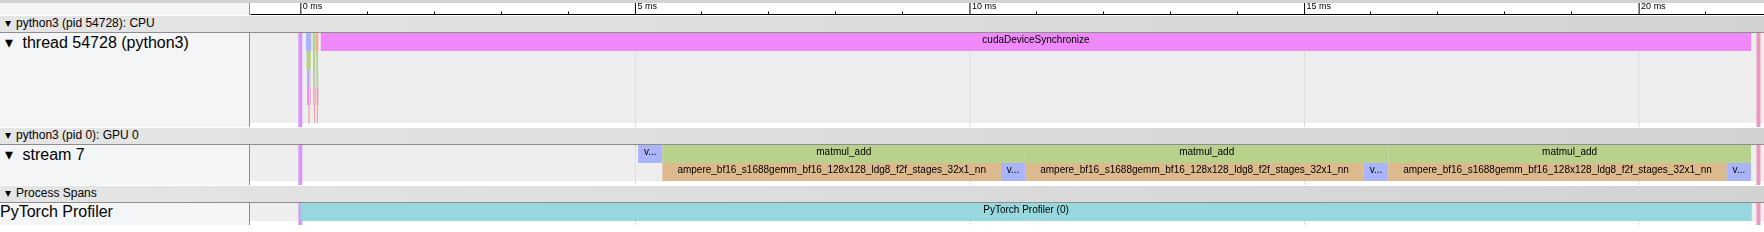
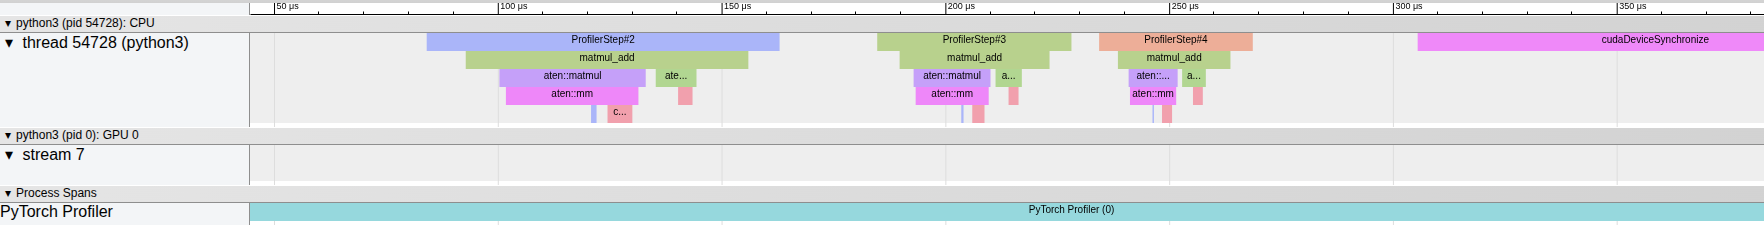

### GPU vs CPU runtime

Below we show the relative fraction of the total runtime spend on GPU as a function of the matrix size with the above parameters and different compilation modes. 
Note that the runtime can vary significantly between runs, so this plot should be taken with a grain of salt.

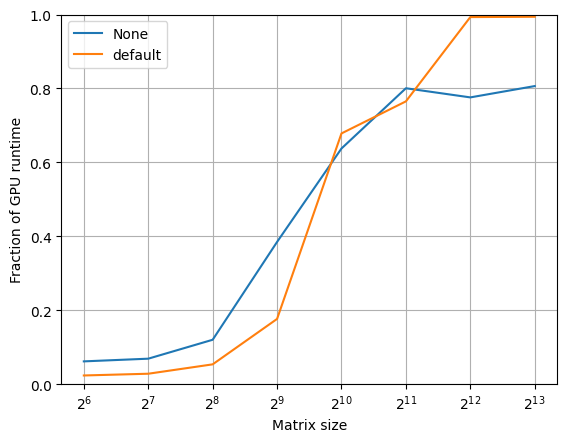

In [4]:
matrix_size = [64, 128, 256, 512, 1024, 2048, 4096, 8192]
cpu_runtime_microseconds_none = [159.604, 153.439, 161.030, 160.213, 313.910, 2707, 21421, 207402]
gpu_runtime_microseconds_none = [9.824, 10.560, 19.326, 61.632, 200.127, 2167, 16618, 167252]
cpu_runtime_microseconds_default = [422.540, 376.609, 361.342, 349.380, 436.184, 2613, 20966, 161898]
gpu_runtime_microseconds_default = [9.889, 10.590, 19.328, 61.632, 295.869, 1999, 20821, 160912]

gpu_runtime_fraction_none = [gpu_runtime_microseconds_none[i] / cpu_runtime_microseconds_none[i] for i in range(len(matrix_size))]
gpu_runtime_fraction_default = [gpu_runtime_microseconds_default[i] / cpu_runtime_microseconds_default[i] for i in range(len(matrix_size))]

plt.plot(matrix_size, gpu_runtime_fraction_none, label='None')
plt.plot(matrix_size, gpu_runtime_fraction_default, label='default')
plt.xlabel("Matrix size")
plt.ylabel("Fraction of GPU runtime")
plt.xscale('log', base=2)
plt.ylim(0,1)
plt.legend()
plt.grid()
plt.show()

Without compilation (mode `None`):
* For small matrices (dimensions below 256), most of the runtime is due to CPU operations (including data transfers to and from the GPU).
* The fraction of the runtime spent on GPU operations increases roughly lnearly in the matrix size between 256 and 2048.
* For larger matrices, about 80% of the runtime is spent on GPU.

Compilation with the `default` mode adds a fixed overhead of about 300µs to the CPU operations, making things worse for small matrices. However, it reduces the total CPU overhead for the largest sizes.

## Part 2: From `nn.Linear` to a Fused MLP

This section follows the HuggingFace [Profiling in PyTorch (Part 2)](https://huggingface.co/blog/torch-mlp-fusion) tutorial.

### Profiling `nn.linear`

In [5]:
# Parameters
batch = 1024
dtype = torch.bfloat16
in_dim = 32
out_dim = 64
compile_mode = None
device = "cuda"
trace_dir = "./temp/02_linear"
warmup_steps = 3
profile_steps = 5
schedule_wait = 1
schedule_warmup = 1
schedule_active = 3
schedule_repeats = 1

x = torch.randn(batch, in_dim, device=device, dtype=dtype)

# Define the linear layer
linear_layer = torch.nn.Linear(in_dim, out_dim, bias=True).to(device, dtype=dtype)
linear_layer.eval()
print(f"Weight shape: {linear_layer.weight.shape}")
print(f"Bias shape: {linear_layer.bias.shape}")
fwd = torch.compile(linear_layer) if compile_mode else linear_layer

# Annotate the function to be profiled
def step():
    with torch.profiler.record_function("linear_fwd"), torch.no_grad():
        return fwd(x)

# Warmup
if warmup_steps > 0:
    for _ in range(warmup_steps):
        step()
    torch.cuda.synchronize()

# Create the directory and paths for ths traces
os.makedirs(trace_dir, exist_ok=True)
compile_tag = "compile" if compile_mode else "eager"
tag = f"{batch}_{in_dim}_{out_dim}_{compile_tag}"
table_path = os.path.join(trace_dir, f"{tag}.txt")
trace_path = os.path.join(trace_dir, f"{tag}.json")

# Create the profile scheduls
schedule = torch.profiler.schedule(
    wait=schedule_wait, warmup=schedule_warmup, 
    active=schedule_active, repeat=schedule_repeats)

# Profiling run
with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CPU,
        torch.profiler.ProfilerActivity.CUDA,
    ],
    schedule=schedule,
    record_shapes=False,
    profile_memory=False,
    with_stack=False,
) as prof:
    for _ in range(profile_steps):
        step()
        prof.step()
torch.cuda.synchronize()

# Save the results
print(f"saving traces ... {trace_path}")
prof.export_chrome_trace(trace_path)
with open(table_path, "w") as f:
    f.write(prof.key_averages().table(sort_by="cuda_time_total", row_limit=-1))

# Print the table
with open(table_path, 'r') as f:
    print(f.read())

Weight shape: torch.Size([64, 32])
Bias shape: torch.Size([64])
saving traces ... ./temp/02_linear/1024_32_64_eager.json
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*        22.36%      32.934us        97.87%     144.161us      48.054us       0.000us         0.00%       7.008us       2.336us             3  
                                             linear_fwd        29.92%      44.074us   

Two observation:
* Matrix multiplication and addition are already fused into a single kernel `aten::addmm` to reduce the number of memory read/write, even with `compile_mode = None`.
* When running without compilation, there is an extra transpose step (`aten::t`) on CPU; it is absent with `compile_mode = "default"`.

### Profiling a 3-layer MLP

In [8]:
# Parameters
batch = 64
dtype = torch.bfloat16
seq = 128
dim = 768
hidden = 3072
compile_mode = None
device = "cuda"
trace_dir = "./temp/03_simple_mlp"
warmup_steps = 3
profile_steps = 5
schedule_wait = 1
schedule_warmup = 1
schedule_active = 3
schedule_repeats = 1

x = torch.randn(batch, seq, dim, device=device, dtype=dtype)

# Define the MLP

class SimpleGeGLUMLP(torch.nn.Module):
    def __init__(self, dim, hidden):
        super().__init__()
        self.gate_proj = torch.nn.Linear(dim, hidden, bias=False)
        self.up_proj = torch.nn.Linear(dim, hidden, bias=False)
        self.down_proj = torch.nn.Linear(hidden, dim, bias=False)

    def forward(self, x):
        g = self.gate_proj(x)
        u = self.up_proj(x)
        h = torch.nn.functional.gelu(g, approximate="tanh")
        m = h * u
        y = self.down_proj(m)
        return y
        
mlp = SimpleGeGLUMLP(dim, hidden).to(device, dtype=torch.bfloat16)
mlp.eval()
fwd = torch.compile(mlp, mode=compile_mode) if compile_mode else mlp

# Annotate the function to be profiled
def step():
    with torch.profiler.record_function("mlp_fwd"), torch.no_grad():
        return fwd(x)

# Warmup
if warmup_steps > 0:
    for _ in range(warmup_steps):
        step()
    torch.cuda.synchronize()

# Create the directory and paths for ths traces
os.makedirs(trace_dir, exist_ok=True)
compile_tag = "compile" if compile_mode else "eager"
tag = f"{batch}_{seq}_{dim}_{hidden}_{compile_tag}"
table_path = os.path.join(trace_dir, f"{tag}.txt")
trace_path = os.path.join(trace_dir, f"{tag}.json")

# Create the profile scheduls
schedule = torch.profiler.schedule(
    wait=schedule_wait, warmup=schedule_warmup, 
    active=schedule_active, repeat=schedule_repeats)

# Profiling run
with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CPU,
        torch.profiler.ProfilerActivity.CUDA,
    ],
    schedule=schedule,
    record_shapes=False,
    profile_memory=False,
    with_stack=False,
) as prof:
    for _ in range(profile_steps):
        step()
        prof.step()
torch.cuda.synchronize()

# Save the results
print(f"saving traces ... {trace_path}")
prof.export_chrome_trace(trace_path)
with open(table_path, "w") as f:
    f.write(prof.key_averages().table(sort_by="cuda_time_total", row_limit=-1))

# Print the table
with open(table_path, 'r') as f:
    print(f.read())

saving traces ... ./temp/03_simple_mlp/64_128_768_3072_eager.json
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                mlp_fwd         0.00%       0.000us         0.00%       0.000us       0.000us      16.167ms        80.44%      16.167ms       5.389ms             3  
                                          ProfilerStep*         0.21%      45.535us        32.69%       7.007ms       2.336ms       0.000us  

/home/florent/python_default_venv/lib/python3.12/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


Let us print some of the metrics with the full kernel names:

In [39]:
def print_profile_metric(metrics):
    '''
    Prints metrics from `prof.key_averages()`

    Arguments:
        metric: A list of pairs of strings. The first string in each pair is the metric to print 
                and the second one is the unit.
    '''
    for event in prof.key_averages():
        print(f"{event.key} :")
        for metric in metrics:
            value = getattr(event, metric[0], "Attribute not found")
            print(f"\t{metric[0]}: {value}{metric[1]}")

print_profile_metric([("self_cpu_time_total", "µs"), ("self_device_time_total", "µs")])

ProfilerStep* :
	self_cpu_time_total: 45.534999999999854µs
	self_device_time_total: 0.0µs
mlp_fwd :
	self_cpu_time_total: 6495.05µs
	self_device_time_total: 0.0µs
aten::linear :
	self_cpu_time_total: 15.28899999999922µs
	self_device_time_total: 0.0µs
aten::t :
	self_cpu_time_total: 22.67µs
	self_device_time_total: 0µs
aten::transpose :
	self_cpu_time_total: 14.033000000000158µs
	self_device_time_total: 0µs
aten::as_strided :
	self_cpu_time_total: 9.15799999999993µs
	self_device_time_total: 0µs
aten::matmul :
	self_cpu_time_total: 21.377999999999105µs
	self_device_time_total: 0.0µs
aten::reshape :
	self_cpu_time_total: 5.447000000000088µs
	self_device_time_total: 0µs
aten::view :
	self_cpu_time_total: 12.987999999999516µs
	self_device_time_total: 0µs
aten::mm :
	self_cpu_time_total: 102.12900000000015µs
	self_device_time_total: 12936.51µs
cudaLaunchKernel :
	self_cpu_time_total: 116.39300000000118µs
	self_device_time_total: 0µs
aten::_unsafe_view :
	self_cpu_time_total: 4.88400000000038

### Using a hand-tuned kernel

In this section, we experiment using the `LigerGEGLUMLP` kernel from the [HuggingFace Hub](https://huggingface.co/kernels/kernels-community/liger-kernels).

In [3]:
from kernels import get_kernel # To dowmload the hand-tuned kernel

# Parameters
batch = 64
dtype = torch.bfloat16
seq = 128
dim = 768
hidden = 3072
compile_mode = None
device = "cuda"
trace_dir = "./temp/03_kernels_mlp"
warmup_steps = 3
profile_steps = 5
schedule_wait = 1
schedule_warmup = 1
schedule_active = 3
schedule_repeats = 1

x = torch.randn(batch, seq, dim, device=device, dtype=dtype)

# Load the layer
class Config:
    hidden_size = dim
    intermediate_size = hidden
    hidden_act = "gelu_pytorch_tanh"
kernels_layers = get_kernel("kernels-community/liger-kernels", version=1).layers
kernels_geglu_mlp = kernels_layers.LigerGEGLUMLP
kernels_geglu_mlp = kernels_geglu_mlp(Config()).to(device=device, dtype=dtype).eval()
fwd = torch.compile(kernels_geglu_mlp, mode=compile_mode) if compile_mode else kernels_geglu_mlp

# Annotate the function to be profiled
def step():
    with torch.profiler.record_function("kernels_mlp_fwd"), torch.no_grad():
        return fwd(x)

# Warmup
if warmup_steps > 0:
    for _ in range(warmup_steps):
        step()
    torch.cuda.synchronize()

# Create the directory and paths for ths traces
os.makedirs(trace_dir, exist_ok=True)
compile_tag = "compile" if compile_mode else "eager"
tag = f"{batch}_{seq}_{dim}_{hidden}_{compile_tag}"
table_path = os.path.join(trace_dir, f"{tag}.txt")
trace_path = os.path.join(trace_dir, f"{tag}.json")

# Create the profile scheduls
schedule = torch.profiler.schedule(
    wait=schedule_wait, warmup=schedule_warmup, 
    active=schedule_active, repeat=schedule_repeats)

# Profiling run
with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CPU,
        torch.profiler.ProfilerActivity.CUDA,
    ],
    schedule=schedule,
    record_shapes=False,
    profile_memory=False,
    with_stack=False,
) as prof:
    for _ in range(profile_steps):
        step()
        prof.step()
torch.cuda.synchronize()

# Save the results
print(f"saving traces ... {trace_path}")
prof.export_chrome_trace(trace_path)
with open(table_path, "w") as f:
    f.write(prof.key_averages().table(sort_by="cuda_time_total", row_limit=-1))

# Print the table
with open(table_path, 'r') as f:
    print(f.read())

/home/florent/python_default_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You are using version 1 of 'kernels-community/liger-kernels', but version 2 is available.
Fetching 20 files: 100%|████████████████████████████████████████████████████████████████████████████████| 20/20 [00:01<00:00, 17.98it/s]


saving traces ... ./temp/03_kernels_mlp/64_128_768_3072_eager.json
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                        kernels_mlp_fwd         0.00%       0.000us         0.00%       0.000us       0.000us      14.892ms        80.92%      14.892ms       4.964ms             3  
                                          ProfilerStep*         0.26%      51.293us         6.11%       1.194ms     398.157us       0.000us 

/home/florent/python_default_venv/lib/python3.12/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


## Part 3: Profiling an attention layer

This section follows the HuggingFace [Profiling in PyTorch (Part 3)](https://huggingface.co/blog/torch-attention-profile) tutorial.

In [3]:
def run_profile():

    # Warmup
    if warmup_steps > 0:
        for _ in range(warmup_steps):
            step()
        torch.cuda.synchronize()
    
    # Create the directory and paths for ths traces
    os.makedirs(trace_dir, exist_ok=True)
    compile_tag = "compile" if compile_mode else "eager"
    tag = f"{batch}_{heads}_{seq}_{head_dim}_{compile_tag}"
    table_path = os.path.join(trace_dir, f"{tag}.txt")
    trace_path = os.path.join(trace_dir, f"{tag}.json")
    
    # Create the profile scheduls
    schedule = torch.profiler.schedule(
        wait=schedule_wait, warmup=schedule_warmup, 
        active=schedule_active, repeat=schedule_repeats)
    
    # Profiling run
    with torch.profiler.profile(
        activities=[
            torch.profiler.ProfilerActivity.CPU,
            torch.profiler.ProfilerActivity.CUDA,
        ],
        schedule=schedule,
        record_shapes=False,
        profile_memory=False,
        with_stack=False,
    ) as prof:
        for _ in range(profile_steps):
            step()
            prof.step()
    torch.cuda.synchronize()
    
    # Save the results
    print(f"saving traces ... {trace_path}")
    prof.export_chrome_trace(trace_path)
    with open(table_path, "w") as f:
        f.write(prof.key_averages().table(sort_by="cuda_time_total", row_limit=-1))
    
    # Print the table
    with open(table_path, 'r') as f:
        print(f.read())

### Naive Attention

In [4]:
class NaiveCausalAttention(torch.nn.Module):
    '''return softmax(Q K^T / sqrt(d) + mask) @ V
       where
         * Q is the Query matrix
         * K is the Key matrix
         * V is the Value matrix
         * d is the attention head dimension
         * softnax is taken over the last dimension
    '''

    def __init__(self, head_dim):
        super().__init__()
        self.scale = 1.0 / sqrt(head_dim)

    def forward(self, q, k, v, mask, in_place_mask=False):
        '''
        Forward pass
        
        Use in-place masking if `in_place_nask` is True (saves runtime and memory but would 
        override values needed for the backward pass; ok here as we run with `torch.no_grad()`)
        '''
        # q, k, v have shape (batch, heads, seq, head_dim)
        scores = torch.matmul(q, k.transpose(-2, -1))    # (batch, heads, seq, seq)
        scores = torch.mul(scores, self.scale)
        if in_place_mask:
            scores = scores.masked_fill_(mask, float("-inf"))
        else:
            scores = scores.masked_fill(mask, float("-inf"))
        attn = torch.softmax(scores, dim=-1)
        out = torch.matmul(attn, v)  # (batch, heads, seq, head_dim)
        return out

# Parameters
batch = 8     # batch size
heads = 16    # number of attention heads
seq = 1024    # sequence length
head_dim = 64 # dimension of an attention head
dtype = torch.bfloat16
compile_mode = None
device = "cuda"
trace_dir = "./temp/04_a_naive_attention"
warmup_steps = 3
profile_steps = 5
schedule_wait = 1
schedule_warmup = 1
schedule_active = 3
schedule_repeats = 1
in_place_mask = False

# Query, Key, and Value matrices
shape = (batch, heads, seq, head_dim)
q = torch.randn(shape, device=device, dtype=dtype)
k = torch.randn(shape, device=device, dtype=dtype)
v = torch.randn(shape, device=device, dtype=dtype)

# Causal mask (for uni-directional prediction)
mask = torch.triu(
    torch.ones(seq, seq, device=device, dtype=torch.bool),
    diagonal=1,
)

# Build the attention layer
attn = NaiveCausalAttention(head_dim).to(device, dtype=dtype)
attn.eval()
fwd = torch.compile(attn, mode=compile_mode) if compile_mode else attn

# Annotate the function to be profiled
def step():
    with torch.profiler.record_function("attn_fwd"), torch.no_grad():
        return fwd(q, k, v, mask, in_place_mask)

run_profile()

saving traces ... ./temp/04_a_naive_attention/8_16_1024_64_eager.json
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               attn_fwd         0.00%       0.000us         0.00%       0.000us       0.000us      28.683ms        77.49%      28.683ms       9.561ms             3  
                                          ProfilerStep*         0.11%      41.799us         1.06%     403.184us     134.395us       0.000

/home/florent/python_default_venv/lib/python3.12/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


**Trace with out-of-place masking:**

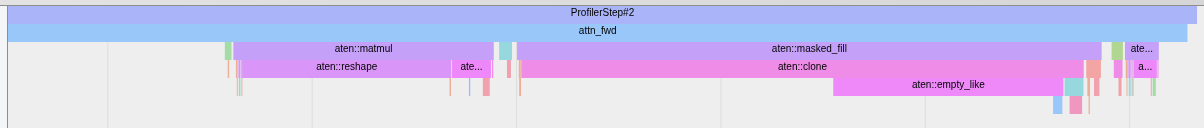
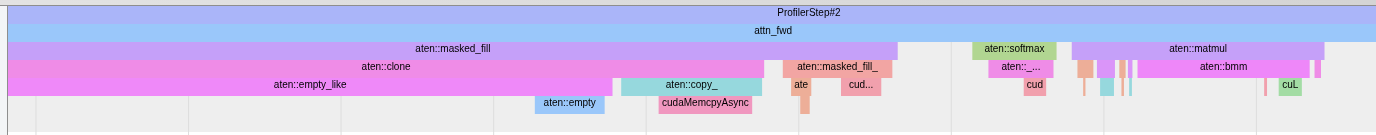
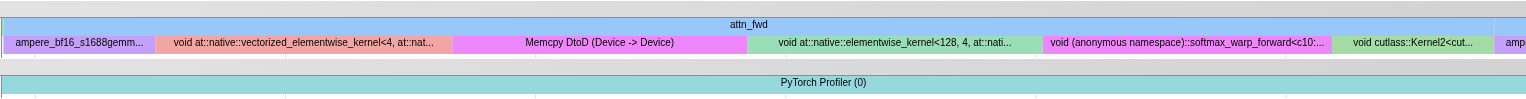

**Trace with in-place masking:**

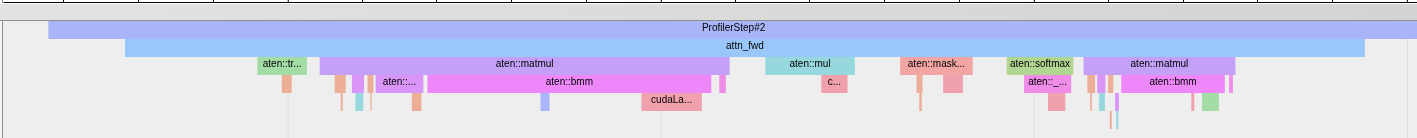
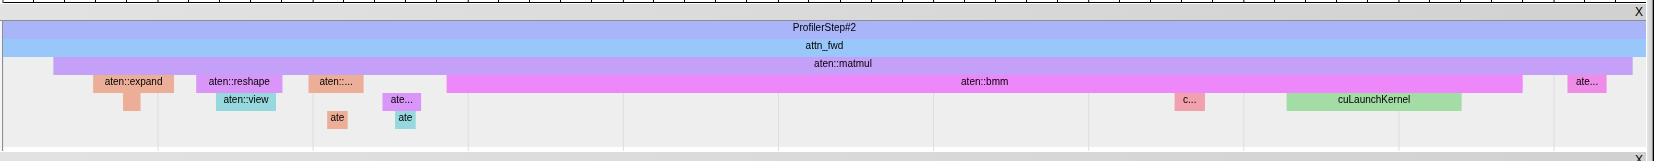
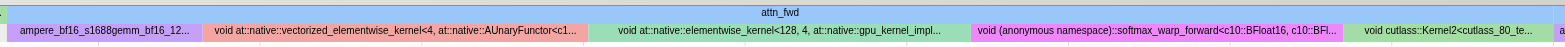

The main difference is the absence of the device-to-device copu before the element-wise multiplication.